# A. Topic Modelling dengan Latent Dirichlet Allocation (LDA)

In [ ]:
import pandas as pd
from google.colab import files

# Upload file CSV
uploaded = files.upload()

# Membaca file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# Menampilkan 10 data pertama
df.head(10)

Saving ulasan_plnmobile_preprocessing.csv to ulasan_plnmobile_preprocessing.csv


,nama,rating,final_text,tanggal,sumber
0,kus wanto,5.0,aplikasi manfaat urus listrik,2025-09-26 00:05:57,ulasan_plnmobile_googleplaystore.csv
1,askhar muda,5.0,bantu proses adu,2025-09-26 00:08:49,ulasan_plnmobile_googleplaystore.csv
2,Heru Cahyono,5.0,mudah cepat tanggap,2025-09-26 00:09:27,ulasan_plnmobile_googleplaystore.csv
3,Venitri Kudji Ratu,5.0,hadir aplikasi ganggu listrik rumah,2025-09-26 00:14:52,ulasan_plnmobile_googleplaystore.csv
4,Felix __,5.0,lapor langsung pln pakai pln mobile mudah cepa...,2025-09-26 00:25:25,ulasan_plnmobile_googleplaystore.csv
5,Baso Itung,5.0,bantu langgan,2025-09-26 00:39:53,ulasan_plnmobile_googleplaystore.csv
6,Omteddy Teddy,5.0,mudah percaya,2025-09-26 00:44:09,ulasan_plnmobile_googleplaystore.csv
7,Misra Misra,5.0,semenjak aplikasi pln mobile mudah laku ganggu...,2025-09-26 00:44:36,ulasan_plnmobile_googleplaystore.csv
8,Rosna Kolo,5.0,pln baik aplikasi pln mobile,2025-09-26 00:44:57,ulasan_plnmobile_googleplaystore.csv
9,izi muhsin,5.0,tingkat layan ulp,2025-09-26 00:46:33,ulasan_plnmobile_googleplaystore.csv


# Mengecek Missing Values

In [ ]:
# Kolom yang akan dicek
columns_to_check = [
    'final_text'
]

# Menghitung jumlah missing values
missing_values = df[columns_to_check].isnull().sum()

# Menampilkan dalam bentuk tabel
missing_values_df = missing_values.reset_index()
missing_values_df.columns = ['Kolom', 'Jumlah Missing']

missing_values_df


,Kolom,Jumlah Missing
0,final_text,0


# Persiapan Data dan Penerapan LDA

In [ ]:
# Memisahkan teks menjadi token (list kata)
df['tokens'] = df['final_text'].apply(lambda x: x.split())
df[['final_text', 'tokens']].head()

# Mengambil seluruh token ulasan
texts = df['tokens'].tolist()

# Contoh hasil
texts[:3]

[['aplikasi', 'manfaat', 'urus', 'listrik'],
 ['bantu', 'proses', 'adu'],
 ['mudah', 'cepat', 'tanggap']]

In [ ]:
!pip install gensim

from gensim.corpora import Dictionary

# Membuat dictionary dari token
dictionary = Dictionary(texts)

# Melihat jumlah kata unik
print(f"Jumlah kata unik: {len(dictionary)}")

# Mengonversi setiap dokumen ke representasi Bag of Words
corpus = [dictionary.doc2bow(text) for text in texts]

# Contoh BoW
corpus[:3]

# Menyiapkan Daftar Penyimpanan Coherence Score
coherence_scores = []

# Mengatur Jumlah Topik yang Diekstrak (10 Topik)
num_topics_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]

# Menentukan Seed untuk Hasil yang Konsisten
random_state = 42

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 18.3 MB/s eta 0:00:00
Jumlah kata unik: 5002


In [ ]:
# Inisialisasi Model dan Penyimpanan Hasil
from gensim.models import LdaModel

lda_models = []

# Pelatihan Model LDA dengan Berbagai Jumlah Topik
for num_topics in num_topics_list:
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=random_state,
        chunksize=100,
        passes=10,
        alpha='auto',
    )

    # Penyimpanan model LDA
    lda_models.append(lda_model)

In [ ]:
print("=== EKSPLORASI AWAL TOPIK LDA ===\n")

for i, num_topics in enumerate(num_topics_list):
    # Menampilkan informasi jumlah topik
    print(f"\nJumlah Topik: {num_topics}")
    print("-" * 40)

    # Mengambil kata kunci topik
    topics = lda_models[i].print_topics(num_words=10)

    # Menampilkan setiap topik
    for idx, topic in topics:
        print(f"Topik {idx + 1}: {topic}")


=== EKSPLORASI AWAL TOPIK LDA ===


Jumlah Topik: 2
----------------------------------------
Topik 1: 0.077*"mudah" + 0.077*"aplikasi" + 0.054*"listrik" + 0.052*"bantu" + 0.022*"lapor" + 0.021*"adu" + 0.021*"token" + 0.021*"bayar" + 0.020*"guna" + 0.020*"beli"
Topik 2: 0.149*"pln" + 0.080*"mobile" + 0.069*"cepat" + 0.055*"layan" + 0.038*"baik" + 0.032*"makin" + 0.022*"tugas" + 0.015*"respon" + 0.012*"langsung" + 0.010*"tangan"

Jumlah Topik: 3
----------------------------------------
Topik 1: 0.109*"mudah" + 0.109*"aplikasi" + 0.076*"listrik" + 0.073*"bantu" + 0.031*"lapor" + 0.030*"token" + 0.030*"adu" + 0.029*"bayar" + 0.028*"guna" + 0.028*"beli"
Topik 2: 0.185*"pln" + 0.099*"mobile" + 0.086*"cepat" + 0.068*"layan" + 0.047*"baik" + 0.037*"makin" + 0.027*"tugas" + 0.018*"respon" + 0.013*"tangan" + 0.013*"moga"
Topik 3: 0.042*"baru" + 0.033*"daya" + 0.027*"pasang" + 0.024*"tambah" + 0.019*"proses" + 0.017*"perlu" + 0.016*"lain" + 0.013*"lewat" + 0.012*"lama" + 0.012*"mau"

Jumlah Topik

In [ ]:
# Import modul CoherenceModel dari gensim
from gensim.models.coherencemodel import CoherenceModel

# List untuk menyimpan nilai coherence score
coherence_scores = []

print("=== HASIL COHERENCE SCORE TOPIC MODELLING LDA ===\n")

# Perulangan untuk setiap model LDA
for i, lda_model in enumerate(lda_models):

    # Membuat objek CoherenceModel
    coherence_model = CoherenceModel(
        model=lda_model,
        texts=texts,
        dictionary=dictionary,
        coherence='c_v'
    )

    # Menghitung coherence score
    coherence = coherence_model.get_coherence()
    coherence_scores.append(coherence)

    # Menampilkan coherence score untuk setiap jumlah topik
    print(f"Jumlah Topik: {num_topics_list[i]} | Coherence Score (c_v): {coherence:.4f}")


=== HASIL COHERENCE SCORE TOPIC MODELLING LDA ===

Jumlah Topik: 2 | Coherence Score (c_v): 0.5543
Jumlah Topik: 3 | Coherence Score (c_v): 0.5190
Jumlah Topik: 4 | Coherence Score (c_v): 0.4495
Jumlah Topik: 5 | Coherence Score (c_v): 0.4210
Jumlah Topik: 6 | Coherence Score (c_v): 0.4275
Jumlah Topik: 7 | Coherence Score (c_v): 0.3707
Jumlah Topik: 8 | Coherence Score (c_v): 0.3383
Jumlah Topik: 9 | Coherence Score (c_v): 0.3904
Jumlah Topik: 10 | Coherence Score (c_v): 0.3971


In [ ]:
# Menentukan Model LDA Terbaik
best_index = coherence_scores.index(max(coherence_scores))
best_num_topics = num_topics_list[best_index]
best_coherence = coherence_scores[best_index]
best_lda_model = lda_models[best_index]

# Menampilkan Hasil Akhir Pemodelan LDA
print("\n=== HASIL AKHIR PEMODELAN LDA ===")
print(f"Jumlah topik terbaik   : {best_num_topics}")
print(f"Coherence score tertinggi (c_v): {best_coherence:.4f}")


=== HASIL AKHIR PEMODELAN LDA ===
Jumlah topik terbaik   : 2
Coherence score tertinggi (c_v): 0.5543


In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

lda_10 = lda_models[num_topics_list.index(10)]

vis = pyLDAvis.gensim_models.prepare(
    lda_10,
    corpus,
    dictionary
)

vis

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
4      0.393907 -0.227643       1        1  28.004234
9      0.178366  0.415306       2        1  21.245762
1     -0.011294 -0.019844       3        1  10.121535
6     -0.009259 -0.003881       4        1   8.966049
7     -0.041972 -0.020721       5        1   8.555825
5     -0.075020 -0.033201       6        1   7.871911
0     -0.086689 -0.025911       7        1   5.760576
2     -0.104452 -0.028855       8        1   4.169279
8     -0.113719 -0.028601       9        1   3.935058
3     -0.129867 -0.026649      10        1   1.369771, topic_info=          Term         Freq        Total Category  logprob  loglift
17         pln  8022.000000  8022.000000  Default  30.0000  30.0000
7        cepat  3247.000000  3247.000000  Default  29.0000  29.0000
8        mudah  5453.000000  5453.000000  Default  28.0000  28.0000
0     aplikasi  5441.000000  5441.000000  Default  27.0000  27.0000
15      mobile  4310.000000  4310.000000  Default  26.0000  26.0000
...        ...          ...          ...      ...      ...      ...
669         on    11.479544    12.157037  Topic10  -4.8522   4.2332
2123        to    10.710381    11.384528  Topic10  -4.9215   4.2295
1242    bangga    10.562433    11.236682  Topic10  -4.9354   4.2286
35      pelang     9.853847    10.528052  Topic10  -5.0049   4.2243
1013     macam     9.660896    10.335136  Topic10  -5.0247   4.2231

[331 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
53        3  0.998009         ada
240       5  0.990098       admin
734       5  0.997929    adminnya
4         7  0.999870         adu
3645      9  0.956893        agam
...     ...       ...         ...
3         1  0.998210        urus
406       3  0.989722       utama
900       3  0.990391  verifikasi
243       5  0.993652         via
911      10  0.955845         wah

[301 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 10, 2, 7, 8, 6, 1, 3, 9, 4])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
pyLDAvis.save_html(vis, "lda_10topics_intertopic.html")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

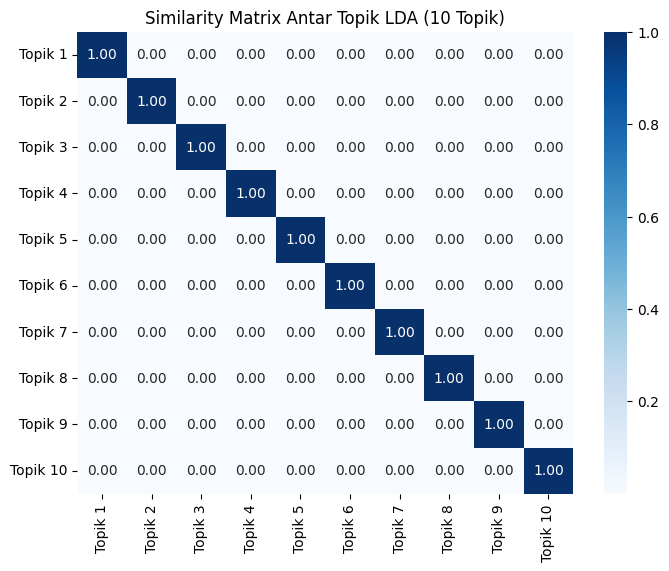

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

topic_word_matrix = lda_10.get_topics()

similarity_matrix = cosine_similarity(topic_word_matrix)

labels = [f"Topik {i+1}" for i in range(10)]

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=labels,
    columns=labels
)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_df, annot=True, cmap="Blues", fmt=".2f")
plt.title("Similarity Matrix Antar Topik LDA (10 Topik)")
plt.show()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

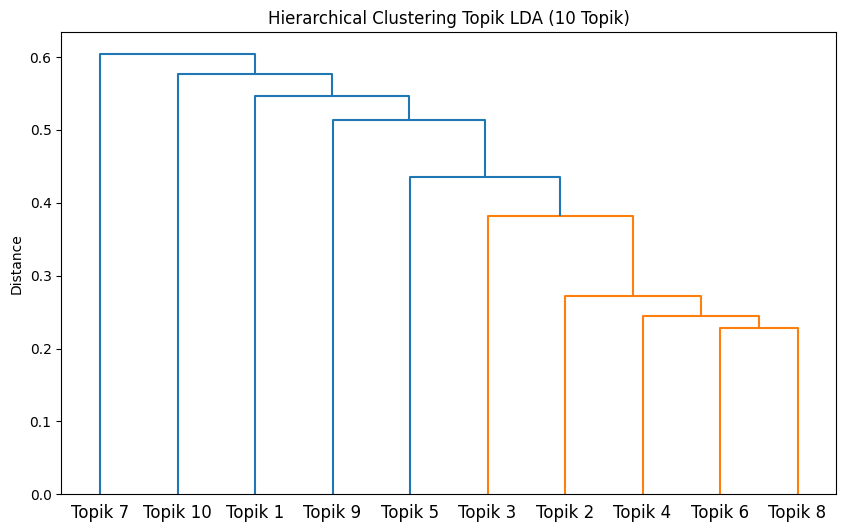

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

linked = linkage(topic_word_matrix, method='ward')

plt.figure(figsize=(10,6))
dendrogram(
    linked,
    labels=labels,
    orientation='top'
)

plt.title("Hierarchical Clustering Topik LDA (10 Topik)")
plt.ylabel("Distance")
plt.show()

# Cosine Similarity

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Ambil distribusi kata per topik dari Gensim LDA
lda_topic_word = lda_model.get_topics()

# Hitung cosine similarity antar topik
lda_similarity = cosine_similarity(lda_topic_word)

# Buat DataFrame
lda_similarity_df = pd.DataFrame(
    lda_similarity,
    index=[f"Topik {i+1}" for i in range(lda_topic_word.shape[0])],
    columns=[f"Topik {i+1}" for i in range(lda_topic_word.shape[0])]
)

lda_similarity_df


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Topik 1,Topik 2,Topik 3,Topik 4,Topik 5,Topik 6,Topik 7,Topik 8,Topik 9,Topik 10
Topik 1,1.000003,0.000236,0.000235,0.000729,0.000119,0.000326,0.000116,0.000299,0.000191,0.000098
Topik 2,0.000236,1.000005,0.000368,0.001320,0.000140,0.000485,0.000162,0.000416,0.000306,0.000121
Topik 3,0.000235,0.000368,1.000009,0.001049,0.000188,0.000509,0.000178,0.000459,0.000284,0.000154
Topik 4,0.000729,0.001320,0.001049,0.999991,0.000763,0.001752,0.000618,0.001612,0.000822,0.000601
Topik 5,0.000119,0.000140,0.000188,0.000763,1.000000,0.000206,0.000075,0.000189,0.000161,0.000048
Topik 6,0.000326,0.000485,0.000509,0.001752,0.000206,1.000011,0.000228,0.000608,0.000416,0.000177
Topik 7,0.000116,0.000162,0.000178,0.000618,0.000075,0.000228,1.000000,0.000210,0.000148,0.000064
Topik 8,0.000299,0.000416,0.000459,0.001612,0.000189,0.000608,0.000210,1.000006,0.000381,0.000163
Topik 9,0.000191,0.000306,0.000284,0.000822,0.000161,0.000416,0.000148,0.000381,1.000005,0.000131
Topik 10,0.000098,0.000121,0.000154,0.000601,0.000048,0.000177,0.000064,0.000163,0.000131,1.000000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
